This notebook is inspired from https://towardsdatascience.com/explain-your-model-with-the-shap-values-bc36aac4de3d

In [91]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification, load_breast_cancer, load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn import preprocessing
from sklearn.ensemble import RandomForestRegressor

!pip install shap
import shap

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: http://artifactory.eu.scor.local/artifactory/api/pypi/pypi/simple


In [58]:
data = load_breast_cancer()
X = data.data
y = data.target

print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [59]:
np.unique(y, return_counts=True)

(array([0, 1]), array([212, 357], dtype=int64))

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state=12)


**1. Change both X_train and X_test by using feature normalization.**

In [62]:
maximum = np.max(X_train)
minimum = np.min(X_train)

X_train = (X_train - minimum)/maximum
X_test = (X_test - minimum)/maximum

**Build a Logistic Regression model**

In [65]:
lr = LogisticRegression(penalty='none')
lr.fit(X_train, y_train)

print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))

0.9648093841642229
0.9385964912280702


c:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1182: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:
lr.predict(X_train)

array([1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,

In [67]:
tree = DecisionTreeRegressor()

params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [1, 2, 5, 10]    
}

grid_search_tree = GridSearchCV(tree, params, cv=5, scoring='accuracy', n_jobs=4)
grid_search_tree.fit(X_train, y_train)

c:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
20 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "c:\Anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "c:\Anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate_pa

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=4,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_split': [1, 2, 5, 10]},
             scoring='accuracy')

In [68]:
print(grid_search_tree.score(X_train, y_train))
print(grid_search_tree.score(X_test, y_test))

1.0
0.9166666666666666


In [69]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

1.0
0.6589945990859991


In [70]:
# Build the model with the random forest regression algorithm:
model = RandomForestRegressor(max_depth=6, random_state=12, n_estimators=100, min_samples_leaf=15)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, min_samples_leaf=15, random_state=12)

In [71]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.877350886807108
0.7278887491871913


### Importance Plot for Each Variable

Using the RandomForestRegressor model trained on the dataset, generate an importance plot for each variable. Utilize the SHAP library to visualize the importance of each feature in the dataset. Ensure that the plot clearly shows the ranking of features based on their importance.

You can use the `shap.summary_plot` function to create the importance plot.

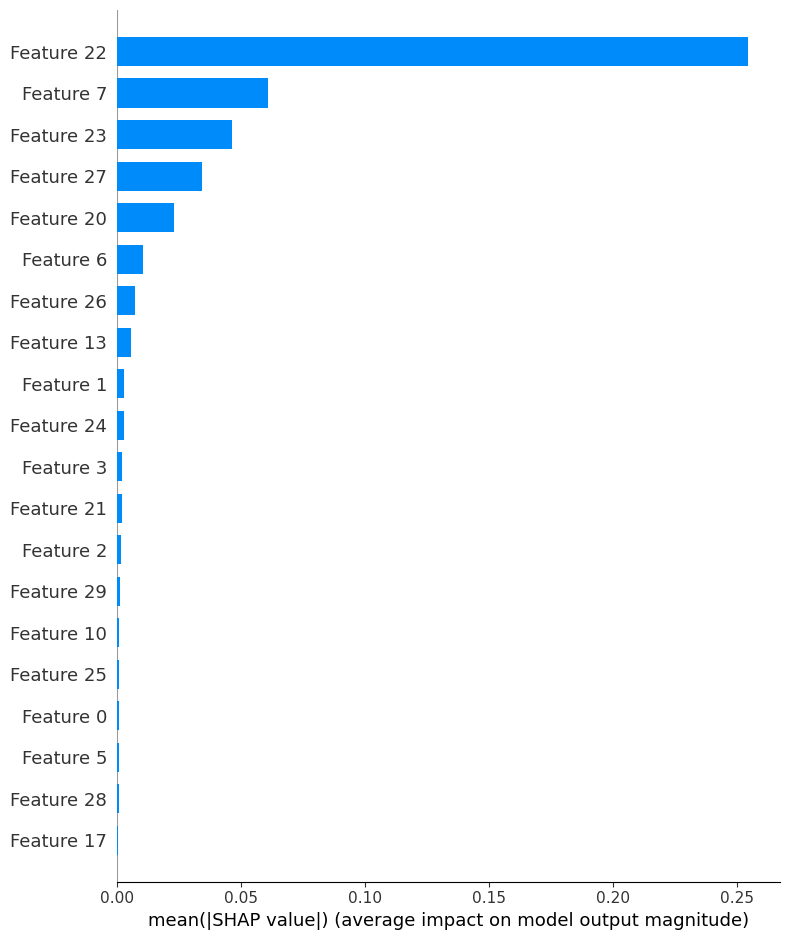

In [74]:
shap_values = shap.TreeExplainer(model).shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")


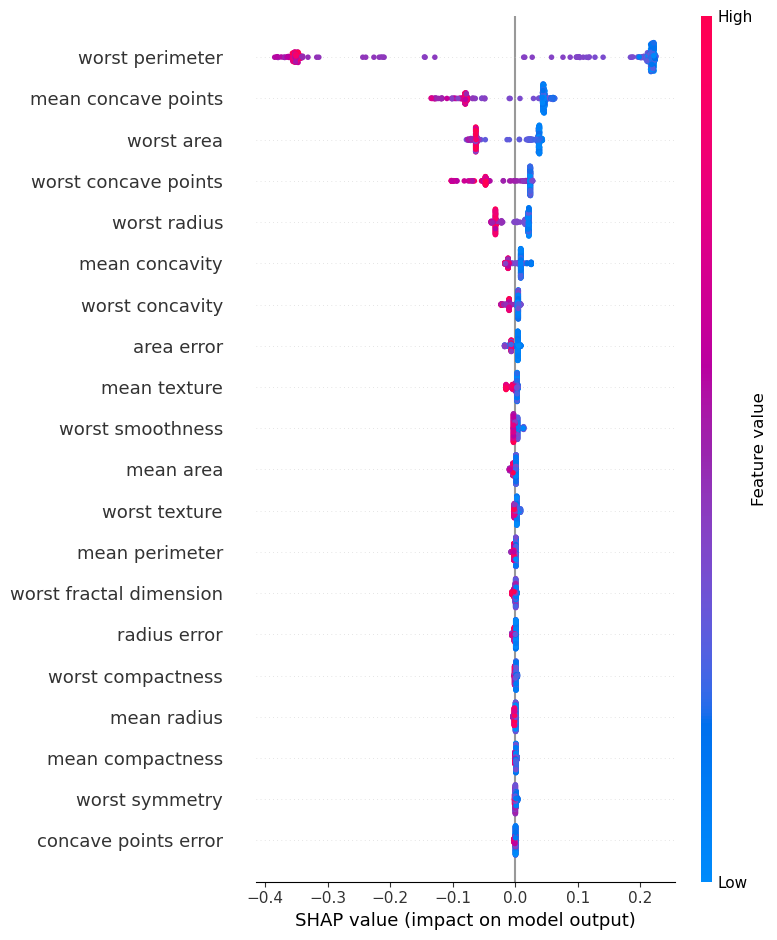

In [76]:
shap.summary_plot(shap_values, X_train, feature_names=data['feature_names'])

How to read this plot:

**Feature importance**: Variables are ranked in descending order.

**Impact**: The horizontal location shows whether the effect of that value is associated with a higher or lower prediction.

**Original value**: Color shows whether that variable is high (in red) or low (in blue) for that observation.

**Correlation**: A high level of the “s5” has a high and positive impact on the disease progression. The “high” comes from the red color, and the “positive” impact is shown on the X-axis. Similarly, we will say the “s3” is negatively correlated with the target variable.

### Dependences plots

In [80]:
data['feature_names']
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

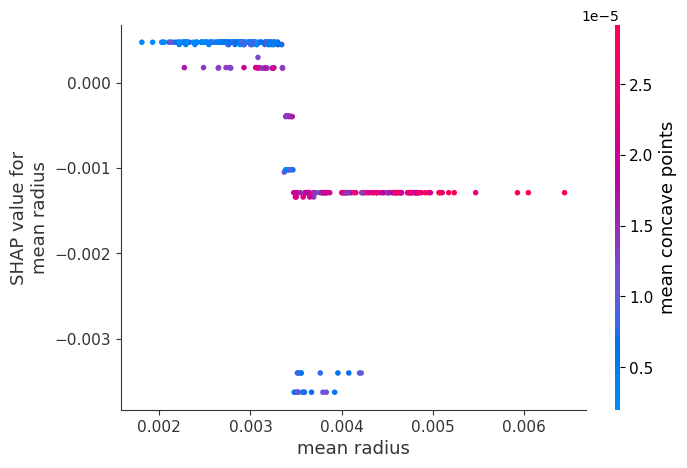

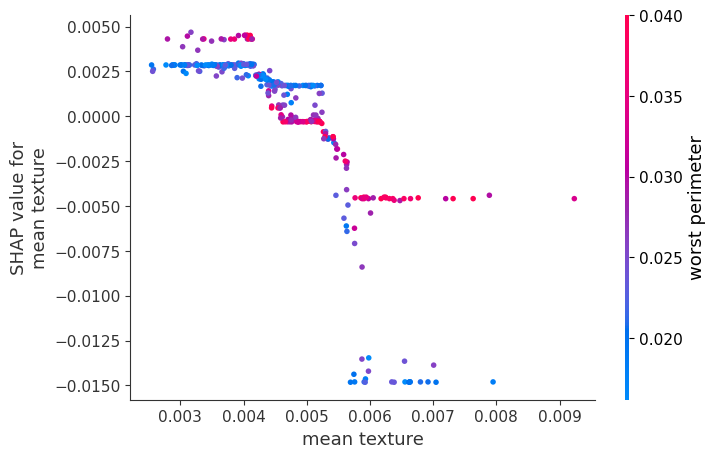

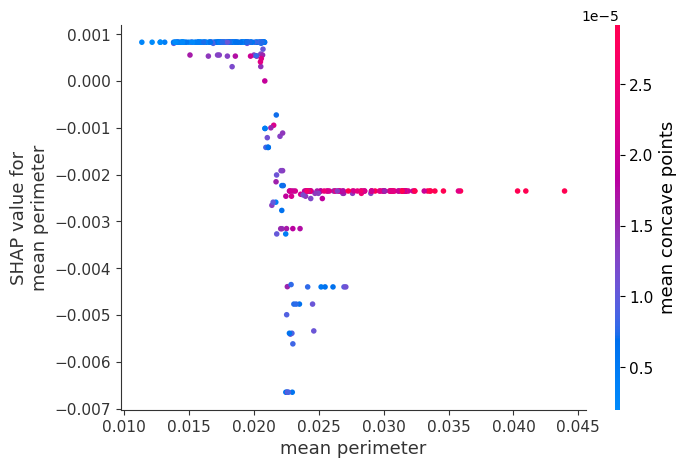

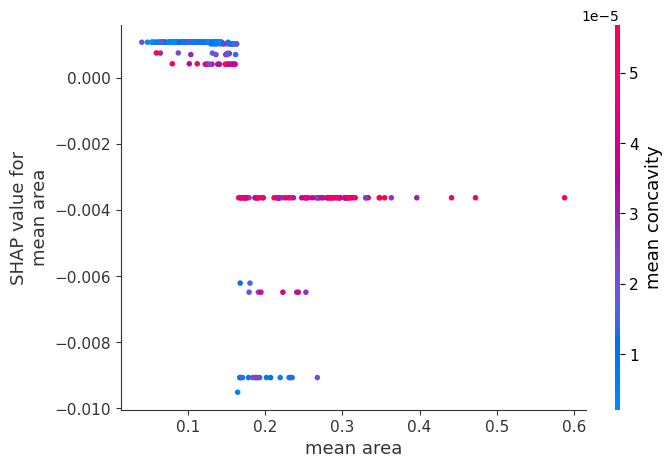

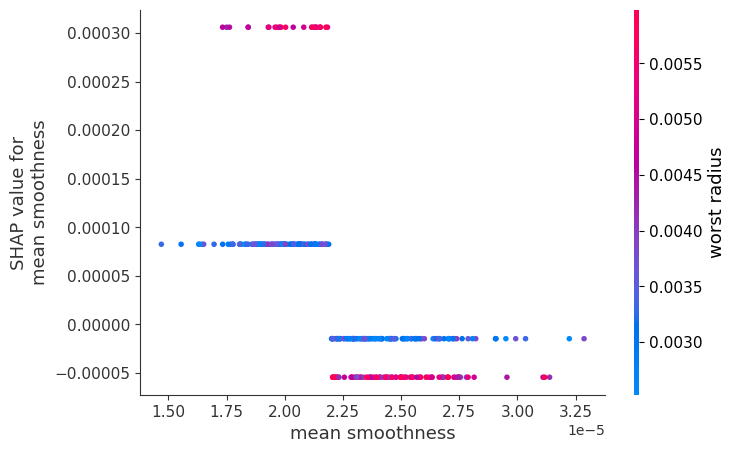

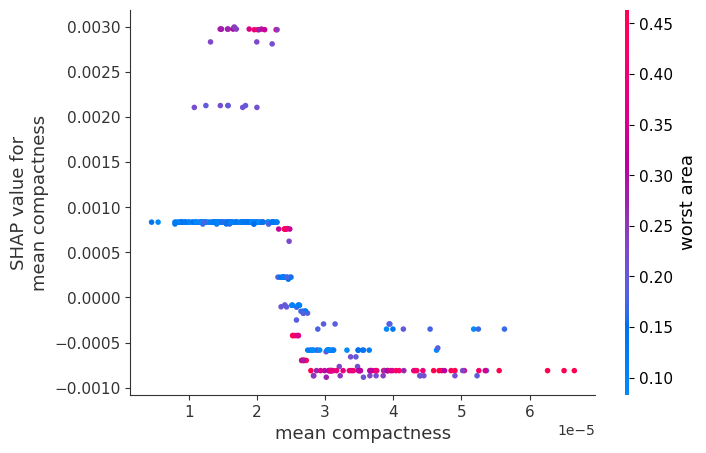

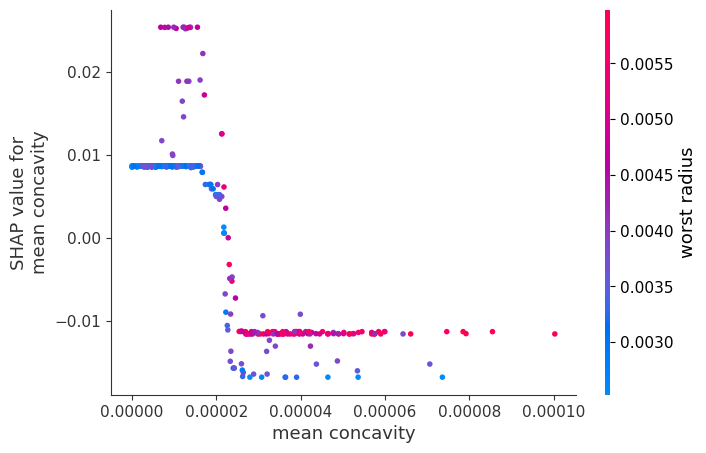

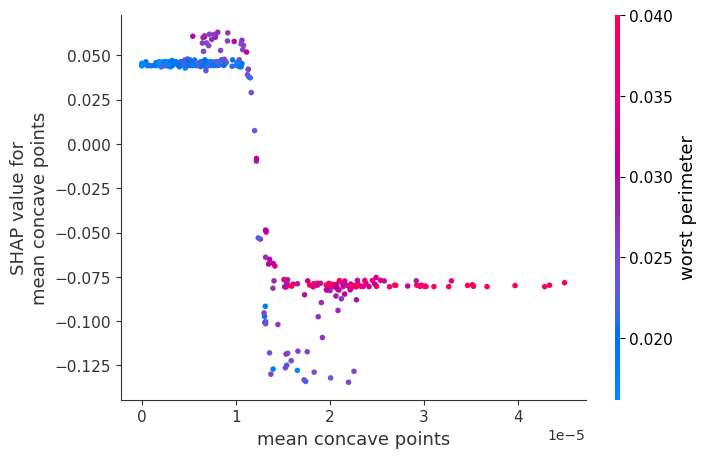

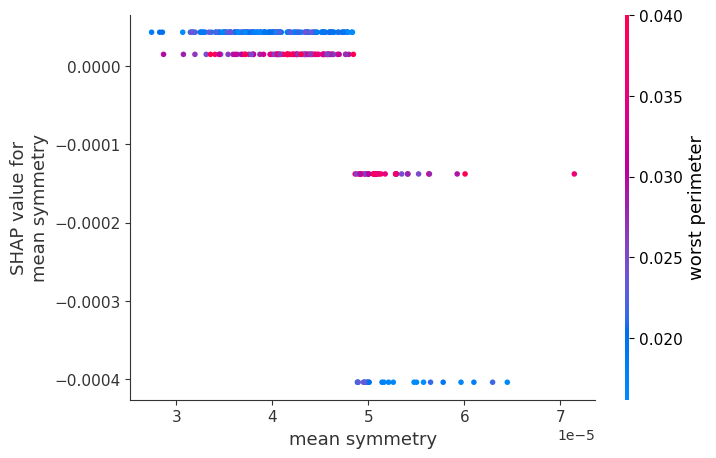

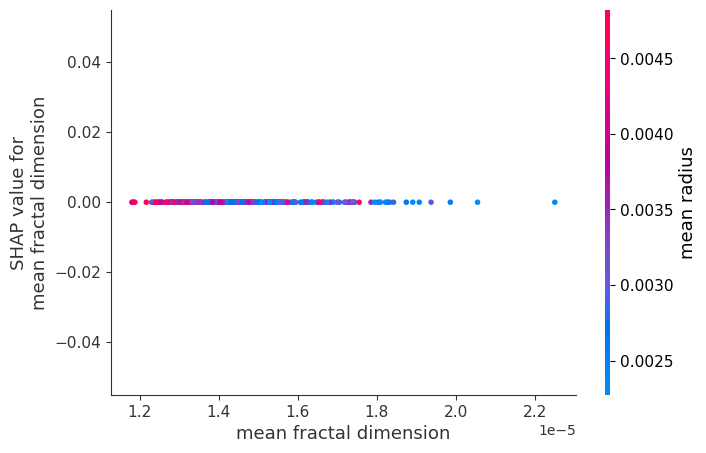

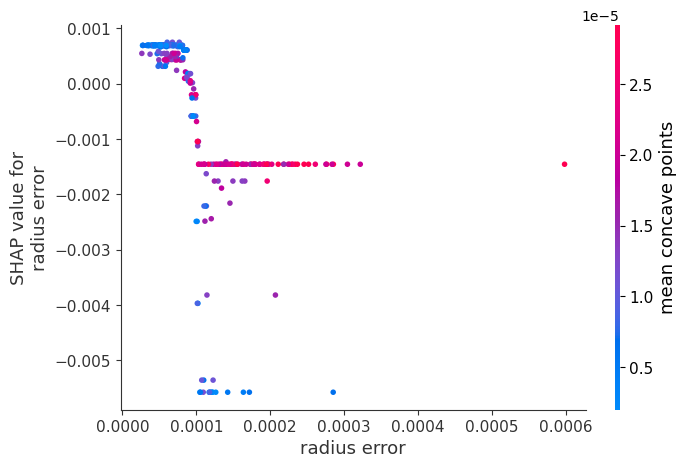

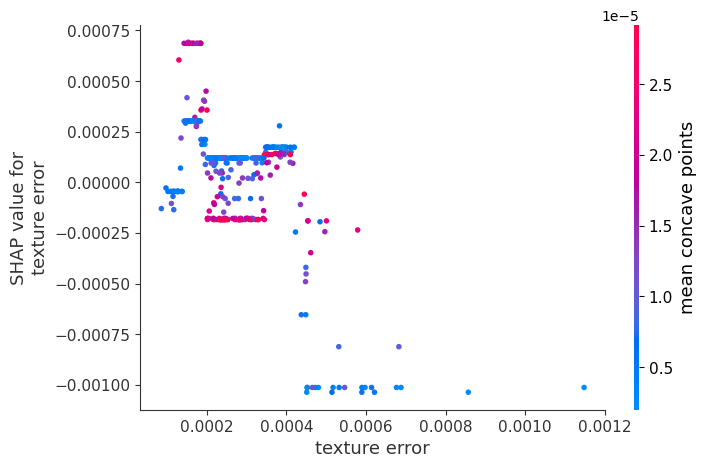

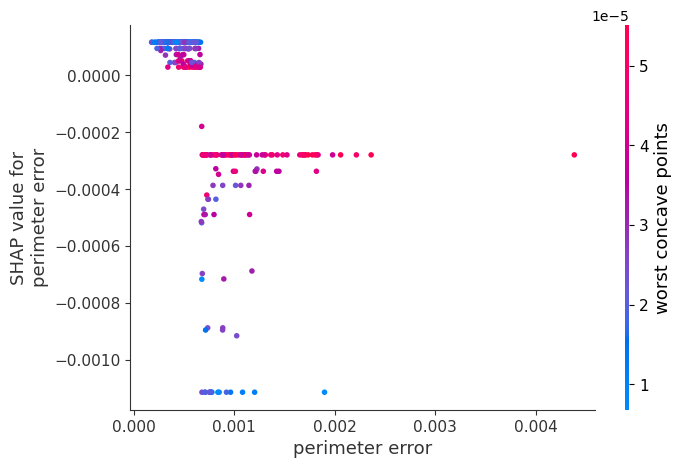

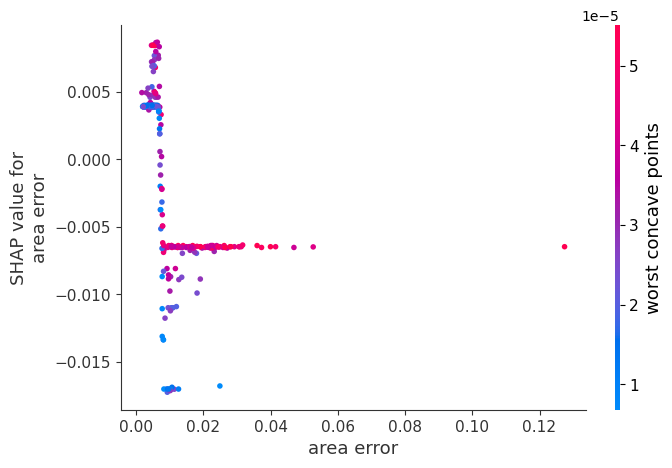

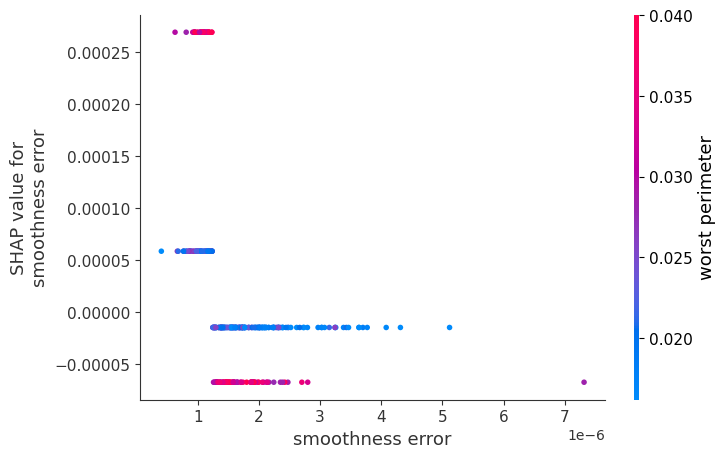

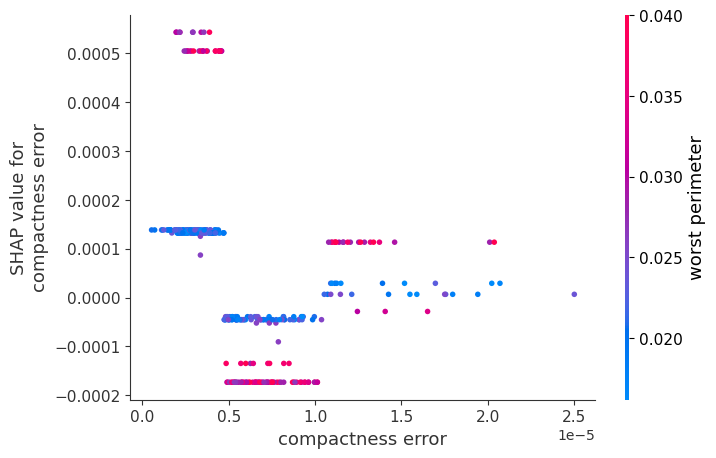

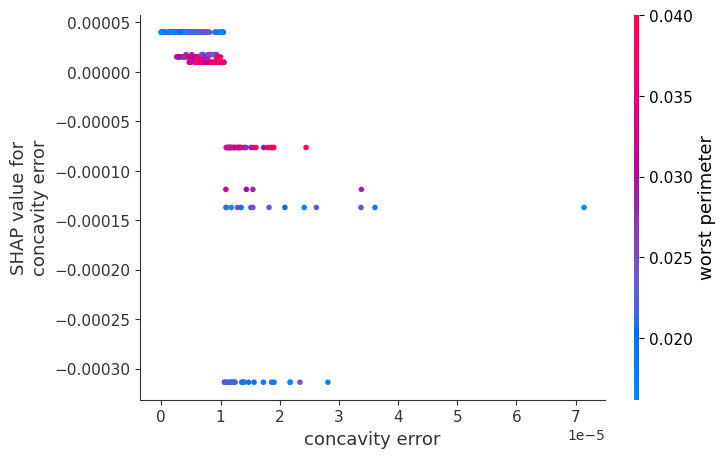

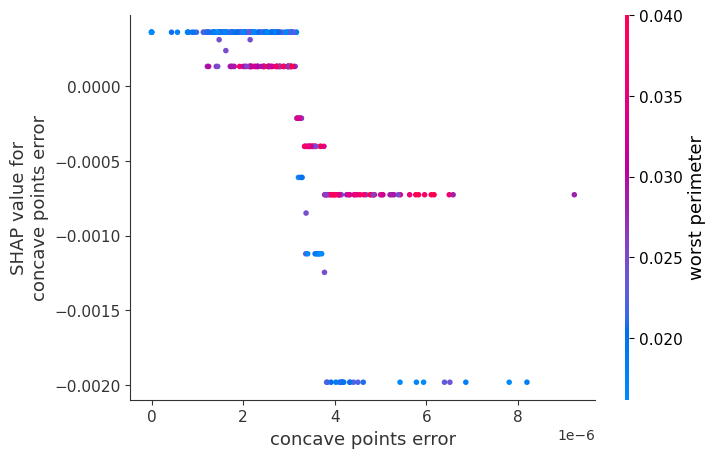

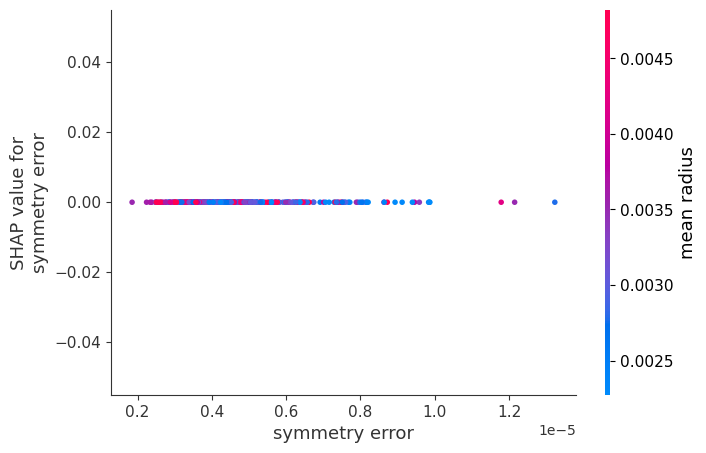

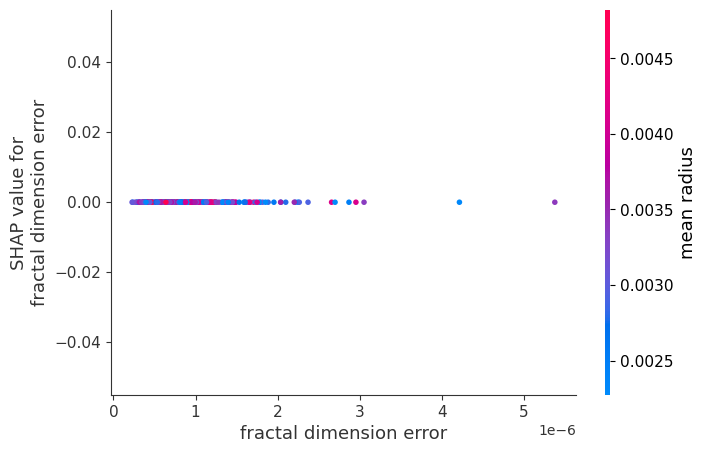

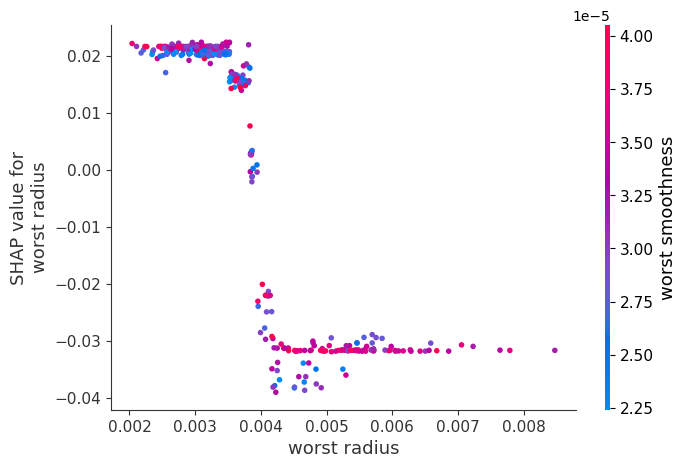

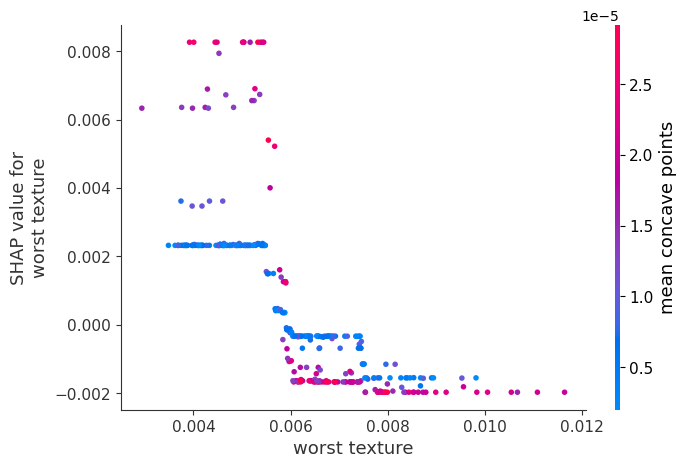

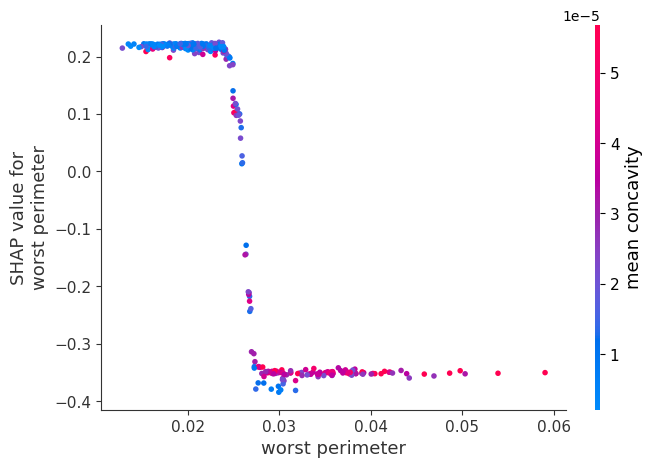

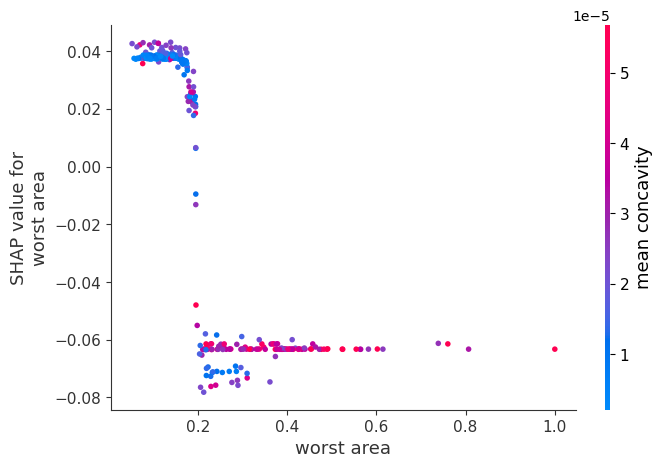

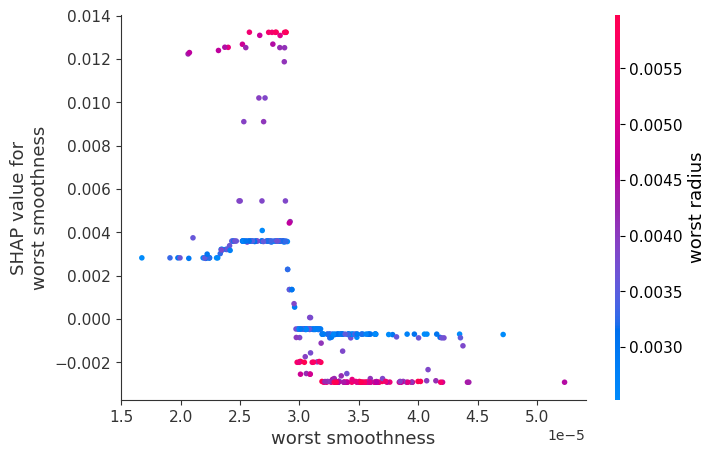

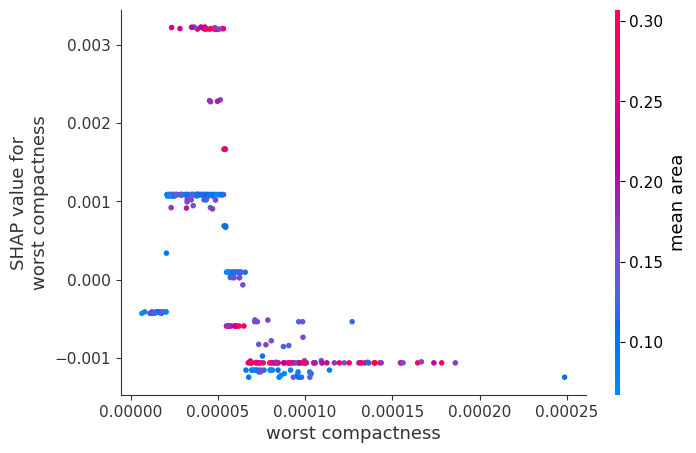

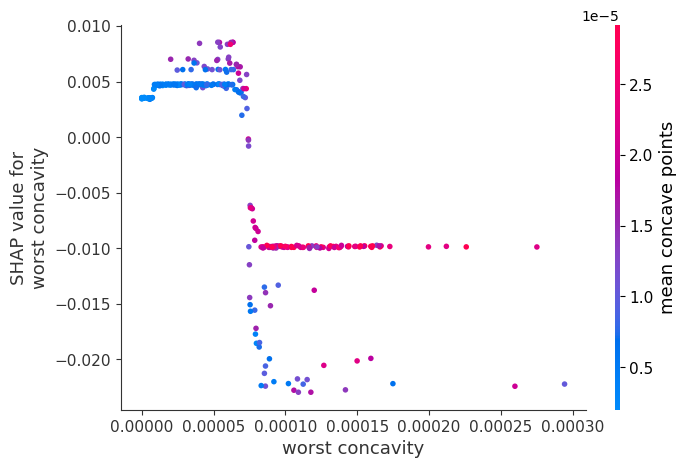

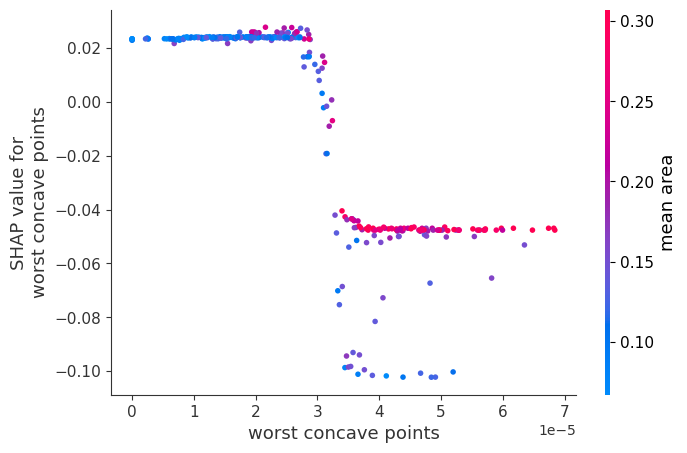

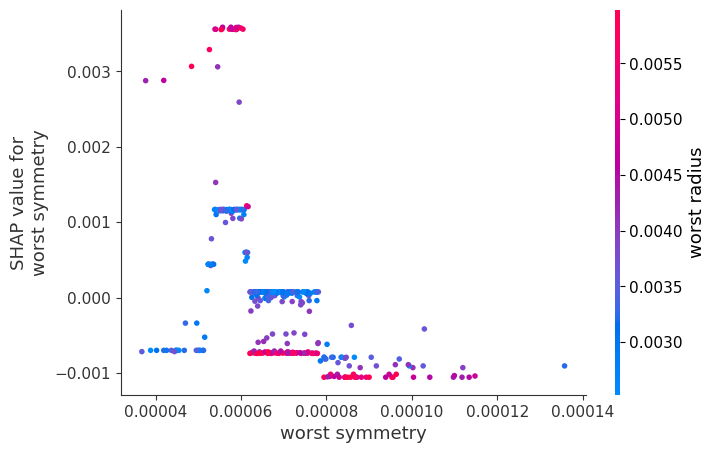

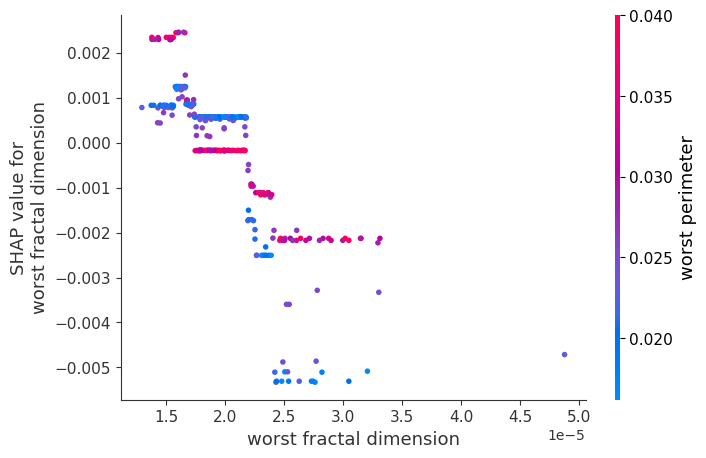

In [81]:
for i in range(X_train.shape[1]):
    shap.dependence_plot(i, shap_values, X_train, feature_names=data['feature_names'])

In [87]:
shap.initjs()

n=172
explainerModel = shap.TreeExplainer(model)
shap_values_Model = explainerModel.shap_values(X_test)
p = shap.force_plot(explainerModel.expected_value, shap_values_Model[n], X_test[[n]], feature_names=data['feature_names'])
print(y_test[n])
p

0


In [88]:
n = 153
explainerModel = shap.TreeExplainer(model)
shap_values_Model = explainerModel.shap_values(X_test)
p = shap.force_plot(explainerModel.expected_value, shap_values_Model[n], X_test[[n]], feature_names=data['feature_names'])
print(y_test[n])
p

0


In [90]:
n=44
explainerModel = shap.TreeExplainer(model)
shap_values_Model = explainerModel.shap_values(X_test)
p = shap.force_plot(explainerModel.expected_value, shap_values_Model[n], X_test[[n]], feature_names=data['feature_names'])
print(y_test[n])
p

1


Redo the same exercise with the diabetes dataset (```load_diabetes```).